# Session 17 — Introduction to Supervised Learning, Regression vs Classification
### Module 5: Supervised Machine Learning

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_breast_cancer
import warnings
warnings.filterwarnings("ignore")

## 1. What Is Supervised Learning?

**Supervised learning** is a type of machine learning where the model learns from data that already has the correct answer (called the **label** or **target**) attached to each example.

- The model is given input features (**X**) and the known correct output (**y**) for many examples.
- It learns a mapping from X to y.
- Once trained, it can predict y for new, unseen X.

**Analogy:** it's like learning with an answer key. You study many solved examples (with the answers given), and eventually you can solve new problems of the same type on your own.

This is different from:
- **Unsupervised learning** — no labels are given; the model finds structure/patterns on its own (e.g. clustering)
- **Reinforcement learning** — an agent learns by receiving rewards/penalties for actions over time


## 2. Regression vs Classification

Supervised learning problems fall into two broad types, based on **what kind of value we are trying to predict**.

| | Regression | Classification |
|---|---|---|
| **Predicts** | A continuous numeric value | A category / class label |
| **Output examples** | Price, temperature, age, sales | Yes/No, Spam/Not Spam, species, disease/no disease |
| **Example question** | "How much will this house sell for?" | "Is this email spam or not?" |
| **Typical algorithms** | Linear Regression | Logistic Regression, KNN, Decision Tree |
| **Evaluation metrics** | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1-score |

**The simplest way to tell them apart:** look at the target column.
- If it's a number that can take *any* value in a range (like 45.7, 100.2, -3) → **Regression**
- If it's a category from a *fixed, limited set* (like "Yes"/"No", or "Class A"/"Class B"/"Class C") → **Classification**


## 3. Real-World Examples

| Scenario | Regression or Classification? | Why |
|---|---|---|
| Predicting a house's selling price | Regression | Price is a continuous number |
| Predicting whether a loan will default | Classification | Outcome is Yes/No |
| Predicting a student's exam score | Regression | Score is a continuous number |
| Predicting whether an email is spam | Classification | Outcome is Spam/Not Spam |
| Predicting tomorrow's temperature | Regression | Temperature is a continuous number |
| Predicting a tumor as malignant or benign | Classification | Outcome is one of two fixed categories |
| Predicting a customer's monthly spend | Regression | Spend is a continuous number |
| Predicting which product category a customer will buy | Classification | Outcome is one of several fixed categories |


## 4. Exploring a Regression Dataset — California Housing

This dataset contains information about housing districts in California, with the goal of predicting **median house value** — a continuous number. This is a classic regression problem.


In [2]:
housing = fetch_california_housing()

df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['MedHouseValue'] = housing.target   # target: median house value (in $100,000s)
df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [3]:
df_housing.shape


(20640, 9)

In [4]:
df_housing.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**About the dataset:** each row represents a block group in California. Features include `MedInc` (median income), `HouseAge`, `AveRooms`, `AveOccup`, `Latitude`, `Longitude`, and more. The target, `MedHouseValue`, is a continuous number — the median house value for that block group.


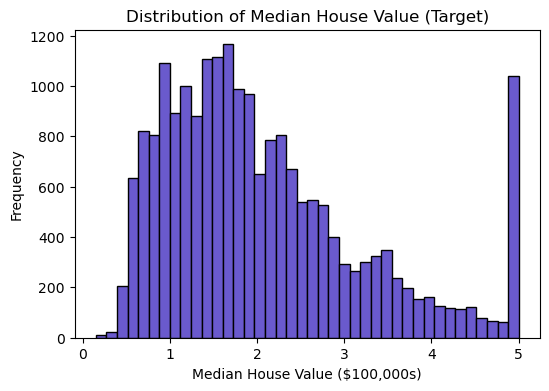

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(df_housing['MedHouseValue'], bins=40, color='slateblue', edgecolor='black')
plt.title('Distribution of Median House Value (Target)')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.show()


**Notice:** the target spreads smoothly across a continuous range — there is no fixed set of categories. This is the visual signature of a regression problem.


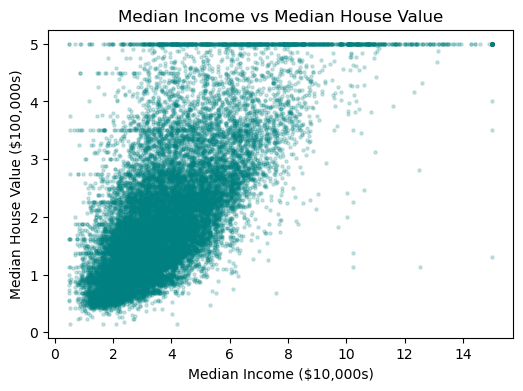

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(df_housing['MedInc'], df_housing['MedHouseValue'], alpha=0.2, s=5, color='teal')
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.show()


## 5. Exploring a Classification Dataset — Breast Cancer Wisconsin

This dataset contains measurements from breast tumor scans, with the goal of predicting whether a tumor is **malignant** or **benign** — a fixed category. This is a classic (binary) classification problem.


In [7]:
cancer = load_breast_cancer()

df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target
df_cancer['diagnosis'] = df_cancer['target'].map({0: 'malignant', 1: 'benign'})
df_cancer.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [8]:
df_cancer.shape


(569, 32)

In [9]:
df_cancer['diagnosis'].value_counts()


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

**About the dataset:** each row represents a tumor sample. Features are numeric measurements taken from the scan (e.g. `mean radius`, `mean texture`, `mean area`). The target, `diagnosis`, is one of exactly two categories: malignant or benign.


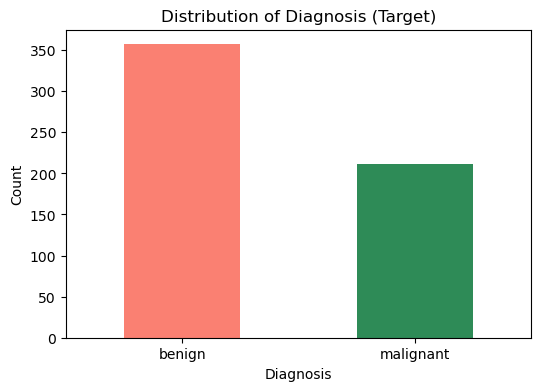

In [10]:
plt.figure(figsize=(6, 4))
df_cancer['diagnosis'].value_counts().plot(kind='bar', color=['salmon', 'seagreen'])
plt.title('Distribution of Diagnosis (Target)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


**Notice:** the target only takes two fixed values, shown here as two distinct bars, not a smooth spread. This is the visual signature of a classification problem.


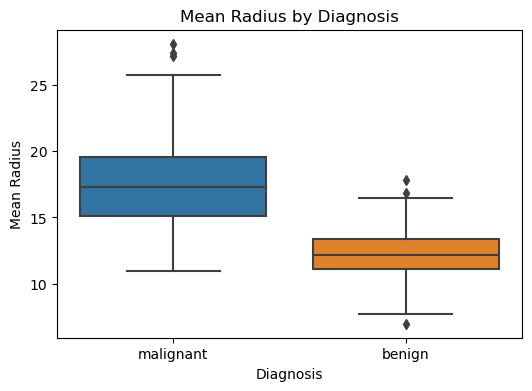

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='diagnosis', y='mean radius', data=df_cancer)
plt.title('Mean Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Radius')
plt.show()


## 6. Side-by-Side Comparison


In [12]:
print("REGRESSION EXAMPLE -- California Housing")
print("Target column: MedHouseValue")
print("Target data type:", df_housing['MedHouseValue'].dtype)
print("Number of unique target values:", df_housing['MedHouseValue'].nunique())
print()
print("CLASSIFICATION EXAMPLE -- Breast Cancer")
print("Target column: diagnosis")
print("Target data type:", df_cancer['diagnosis'].dtype)
print("Number of unique target values:", df_cancer['diagnosis'].nunique())


REGRESSION EXAMPLE -- California Housing
Target column: MedHouseValue
Target data type: float64
Number of unique target values: 3842

CLASSIFICATION EXAMPLE -- Breast Cancer
Target column: diagnosis
Target data type: object
Number of unique target values: 2


**Key takeaway:** the housing target has thousands of unique continuous values, while the cancer target has exactly 2 unique fixed categories. Checking `.nunique()` and the data type of your target column is a quick, practical way to confirm which type of problem you're dealing with.


## 7. A First Look at Fitting a Model

The full details of building, training, and evaluating models are covered in the next several sessions (train-test split, Linear Regression, Logistic Regression, KNN, Decision Trees). For now, here is just a glimpse of how the two problem types connect to two different algorithms.


In [17]:
from sklearn.linear_model import LinearRegression

# Using just one feature for a simple first look
X_reg = df_housing[['MedInc']]
y_reg = df_housing['MedHouseValue']

reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)

sample_income = [[5.0]]   # median income of 50,000 dollars
predicted_value = reg_model.predict(sample_income)
print("Predicted median house value:", predicted_value[0], "(in $100,000s)")

Predicted median house value: 2.5405482271274926 (in $100,000s)


In [19]:
'''California Housing Dataset
        │
        ▼
Feature: MedInc
        │
        ▼
Target: MedHouseValue
        │
        ▼
LinearRegression()
        │
        ▼
fit(X_reg, y_reg)
        │
 Learns Best-Fit Line
        │
        ▼
sample_income = [[5.0]]
        │
        ▼
predict()
        │
        ▼
Predicted House Value'''

'California Housing Dataset\n        │\n        ▼\nFeature: MedInc\n        │\n        ▼\nTarget: MedHouseValue\n        │\n        ▼\nLinearRegression()\n        │\n        ▼\nfit(X_reg, y_reg)\n        │\n Learns Best-Fit Line\n        │\n        ▼\nsample_income = [[5.0]]\n        │\n        ▼\npredict()\n        │\n        ▼\nPredicted House Value'

Notice the regression model predicts a **specific number** — it could be 2.3, 2.31, 2.309, anything on a continuous scale.

In [18]:
from sklearn.linear_model import LogisticRegression

# Using just one feature for a simple first look
X_clf = df_cancer[['mean radius']]
y_clf = df_cancer['target']

clf_model = LogisticRegression()
clf_model.fit(X_clf, y_clf)

sample_radius = [[15.0]]
predicted_class = clf_model.predict(sample_radius)
predicted_label = 'benign' if predicted_class[0] == 1 else 'malignant'
print("Predicted diagnosis:", predicted_label)


Predicted diagnosis: malignant


Notice the classification model predicts a **fixed category** — it can only ever say "malignant" or "benign", never a value in between.

> These two cells are just a preview. In the coming sessions we will properly cover train-test splitting, model evaluation, and how to build these models with multiple features rather than just one.


In [20]:
'''Breast Cancer Dataset
        │
        ▼
Feature: mean radius
        │
        ▼
Target: benign / malignant
        │
        ▼
LogisticRegression()
        │
        ▼
fit(X_clf, y_clf)
        │
 Learns the sigmoid curve
        │
        ▼
sample_radius = [[15.0]]
        │
        ▼
predict()
        │
        ▼
Predicted Class (0 or 1)
        │
        ▼
Convert to Label
        │
        ▼
Print Diagnosis'''

'Breast Cancer Dataset\n        │\n        ▼\nFeature: mean radius\n        │\n        ▼\nTarget: benign / malignant\n        │\n        ▼\nLogisticRegression()\n        │\n        ▼\nfit(X_clf, y_clf)\n        │\n Learns the sigmoid curve\n        │\n        ▼\nsample_radius = [[15.0]]\n        │\n        ▼\npredict()\n        │\n        ▼\nPredicted Class (0 or 1)\n        │\n        ▼\nConvert to Label\n        │\n        ▼\nPrint Diagnosis'

## 8. Quick Decision Guide — Is It Regression or Classification?

Ask these questions about your target column:

1. **Can the target take infinitely many values within a range?** (e.g. price, temperature, age) → Regression
2. **Is the target limited to a small, fixed set of categories?** (e.g. Yes/No, species names, star ratings as categories) → Classification
3. **Would it make sense to say "the answer was off by 2.5"?** If yes → Regression. If the answer is either exactly right or exactly wrong (e.g. predicted "cat" but it was "dog") → Classification.

**Tricky case:** predicting a star rating (1 to 5) can be treated as *either*, depending on the goal — as classification if we only care about the exact category, or as regression if we care about the fact that a prediction of 4 is "closer" to 5 than a prediction of 1.


## 9. Hands-on Practice Exercise 1 — Identify the Problem Type

For each scenario below, state whether it is a regression or classification problem, and briefly justify why:

1. Predicting the number of units a store will sell next month
2. Predicting whether a credit card transaction is fraudulent
3. Predicting a patient's blood pressure reading
4. Predicting which genre a movie belongs to
5. Predicting the age of a person from a photo
6. Predicting whether a customer will churn (leave) or stay


*Write your answers here:*

1.
2.
3.
4.
5.
6.


## 10. Hands-on Practice Exercise 2 — Explore the Datasets

Using `df_housing` and `df_cancer`:

1. Find the minimum and maximum values of `MedHouseValue`. Does this range support it being a regression target?
2. Find all unique values in `df_cancer['diagnosis']`. Does this support it being a classification target?
3. Create a histogram of the `HouseAge` feature in `df_housing`
4. Create a bar chart of `mean texture` averaged by `diagnosis` in `df_cancer`


In [15]:
# Write your solution here



## 11. Hands-on Practice Exercise 3 — Your Own Example

1. Think of a real-world prediction problem from a domain you're interested in (sports, health, finance, retail, etc.)
2. State clearly whether it is regression or classification
3. Identify what the target column would look like (its data type and possible values)
4. Identify 2-3 features that might help predict that target


*Write your answer here:*



## Key Terms Glossary

| Term | Meaning |
|---|---|
| Supervised learning | Learning from labeled data (inputs paired with known correct outputs) |
| Features (X) | The input variables used to make a prediction |
| Target / Label (y) | The known correct output the model learns to predict |
| Regression | Predicting a continuous numeric value |
| Classification | Predicting a category from a fixed set of classes |
| Binary classification | Classification with exactly two possible categories |
| Multi-class classification | Classification with more than two possible categories |
| `.nunique()` | Quick way to check how many distinct values a column has |


## Common Mistakes to Avoid

- Assuming a numeric-looking column is automatically a regression target (e.g. a "rating 1-5" or "class 0/1/2" column can actually be a classification target with numeric-looking labels)
- Confusing the number of *features* with the number of *targets* — supervised learning is defined by what you are predicting, not how many inputs you have
- Choosing an algorithm before identifying the problem type — the choice of Linear Regression vs Logistic Regression, for example, depends entirely on whether the target is continuous or categorical
- Forgetting that classification target labels are often encoded as numbers (like 0 and 1) but still represent categories, not continuous values


## Homework / Practice Assignment

1. Find 3 real datasets or real-world scenarios (from news, work, or personal interest) — for each, decide if it's regression or classification and justify your reasoning
2. Load either `df_housing` or `df_cancer` fresh and write 3-4 sentences describing the dataset and its target, similar to the "About the dataset" sections in this notebook
3. Come prepared with 2 questions/doubts for the next session on the ML workflow: train-test split, dataset preparation, and pipeline overview
